In [1]:
# House Price Prediction
# CloudExify Data Science Internship — Month 2, Project 3
# Regression: Linear Regression vs Random Forest

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv('house_prices.csv')

print(df.head())
print(df.describe())
print(df.isnull().sum())
print(df.columns)

   Area  Bedrooms   Age Location       Price
0  1360         2   1.0    North   5675000.0
1  4272         5  14.0     West  15174000.0
2  3592         2  10.0     East  14054000.0
3   966         2   7.0     East   4288000.0
4  4926         2  25.0    North  19797000.0
              Area    Bedrooms         Age         Price
count   400.000000  400.000000  388.000000  4.000000e+02
mean   2803.600000    3.002500   20.311856  1.060430e+07
std    1254.644564    1.463848   12.038833  4.650875e+06
min     504.000000    1.000000    0.000000  1.718000e+06
25%    1684.000000    2.000000    9.000000  6.560000e+06
50%    2930.000000    3.000000   21.000000  1.073650e+07
75%    3817.250000    4.000000   31.000000  1.428950e+07
max    4999.000000    5.000000   39.000000  2.115300e+07
Area         0
Bedrooms     0
Age         12
Location     0
Price        0
dtype: int64
Index(['Area', 'Bedrooms', 'Age', 'Location', 'Price'], dtype='str')


In [4]:
df = df.dropna()

X = df[['Area', 'Bedrooms', 'Age', 'Location']]
y = df['Price']

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

Training set: 310
Test set: 78


In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"R² (Train): {r2_train:.3f}")
print(f"R² (Test): {r2_test:.3f}")
print(f"RMSE: Rs {rmse_test:,.0f}")

R² (Train): 0.993
R² (Test): 0.991
RMSE: Rs 403,323


In [6]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R²: {r2_rf:.3f}")
print(f"Random Forest RMSE: Rs {rmse_rf:,.0f}")

if r2_rf > r2_test:
    print("Random Forest is better!")
    best_model = rf_model
else:
    print("Linear Regression is better!")
    best_model = lr_model

Random Forest R²: 0.990
Random Forest RMSE: Rs 427,109
Linear Regression is better!


          Feature  Importance
0            Area    0.974985
4  Location_North    0.009079
6   Location_West    0.005487
1        Bedrooms    0.003094
2             Age    0.003072
3   Location_East    0.002373
5  Location_South    0.001910


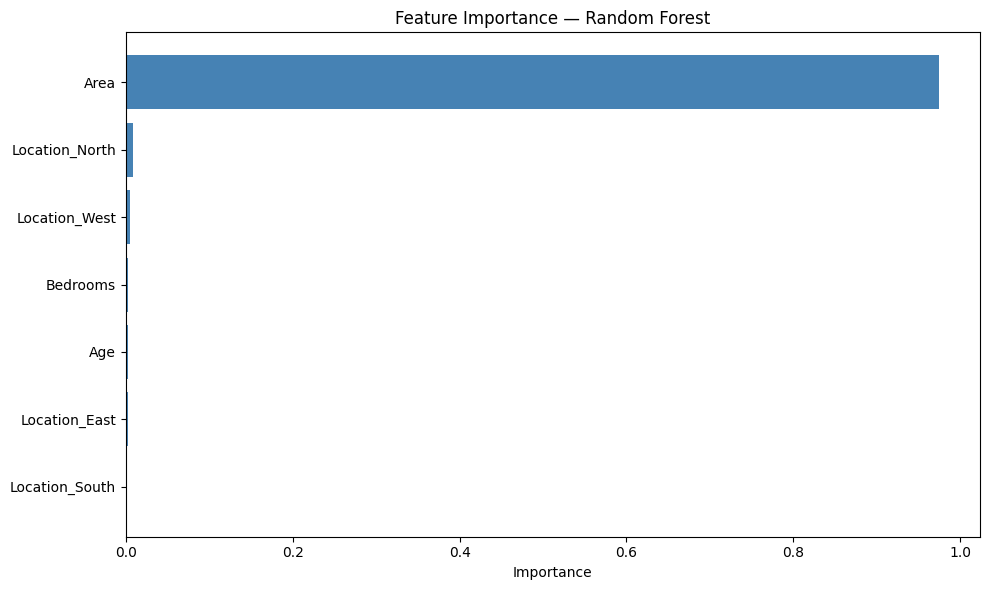

In [8]:
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
new_house = pd.DataFrame({
    'Area': [350],
    'Bedrooms': [4],
    'Age': [10],
    'Location_North': [1],
    'Location_South': [0],
    'Location_East': [0],
    'Location_West': [0]
})

# align columns with training data (in case of missing dummy columns)
new_house = new_house.reindex(columns=X.columns, fill_value=0)

predicted_price = best_model.predict(new_house)
print(f"Predicted price: Rs {predicted_price[0]:,.0f}")

Predicted price: Rs 2,867,019


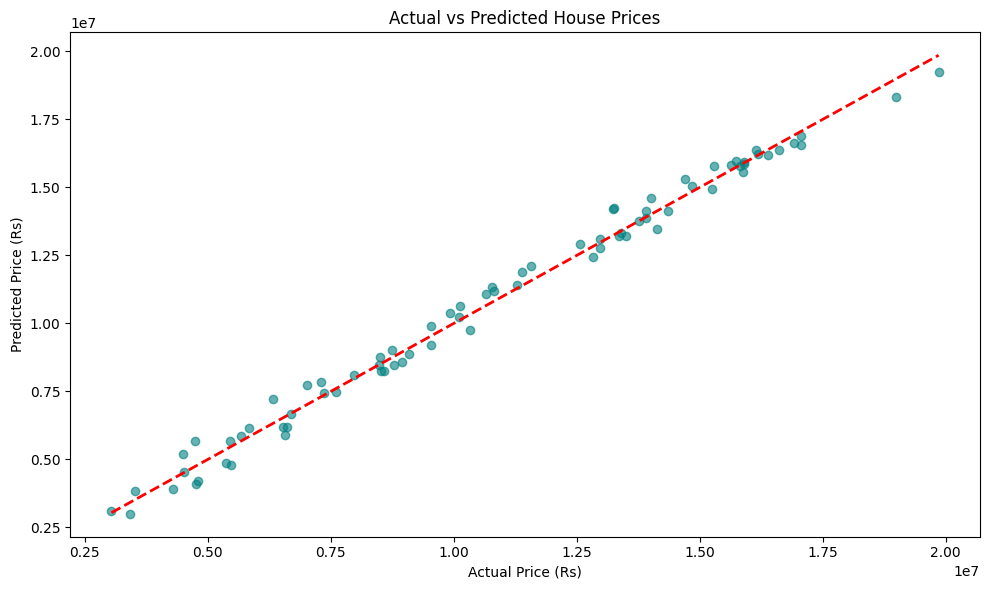

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Rs)')
plt.ylabel('Predicted Price (Rs)')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()